In [2]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit
import yaml
from matplotlib import axes

In [3]:
import os
os.getcwd()

'/export/scratch/users/rodr1001/my_code/my_code/ldmx/hgcroc/pedestal_data/data'

In [4]:
pedestal = pd.read_csv('pedestal_20250818_210701.csv') #leveled and shifted inv-vref 0 = 527, inv_vref 1 = 4

In [5]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [6]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

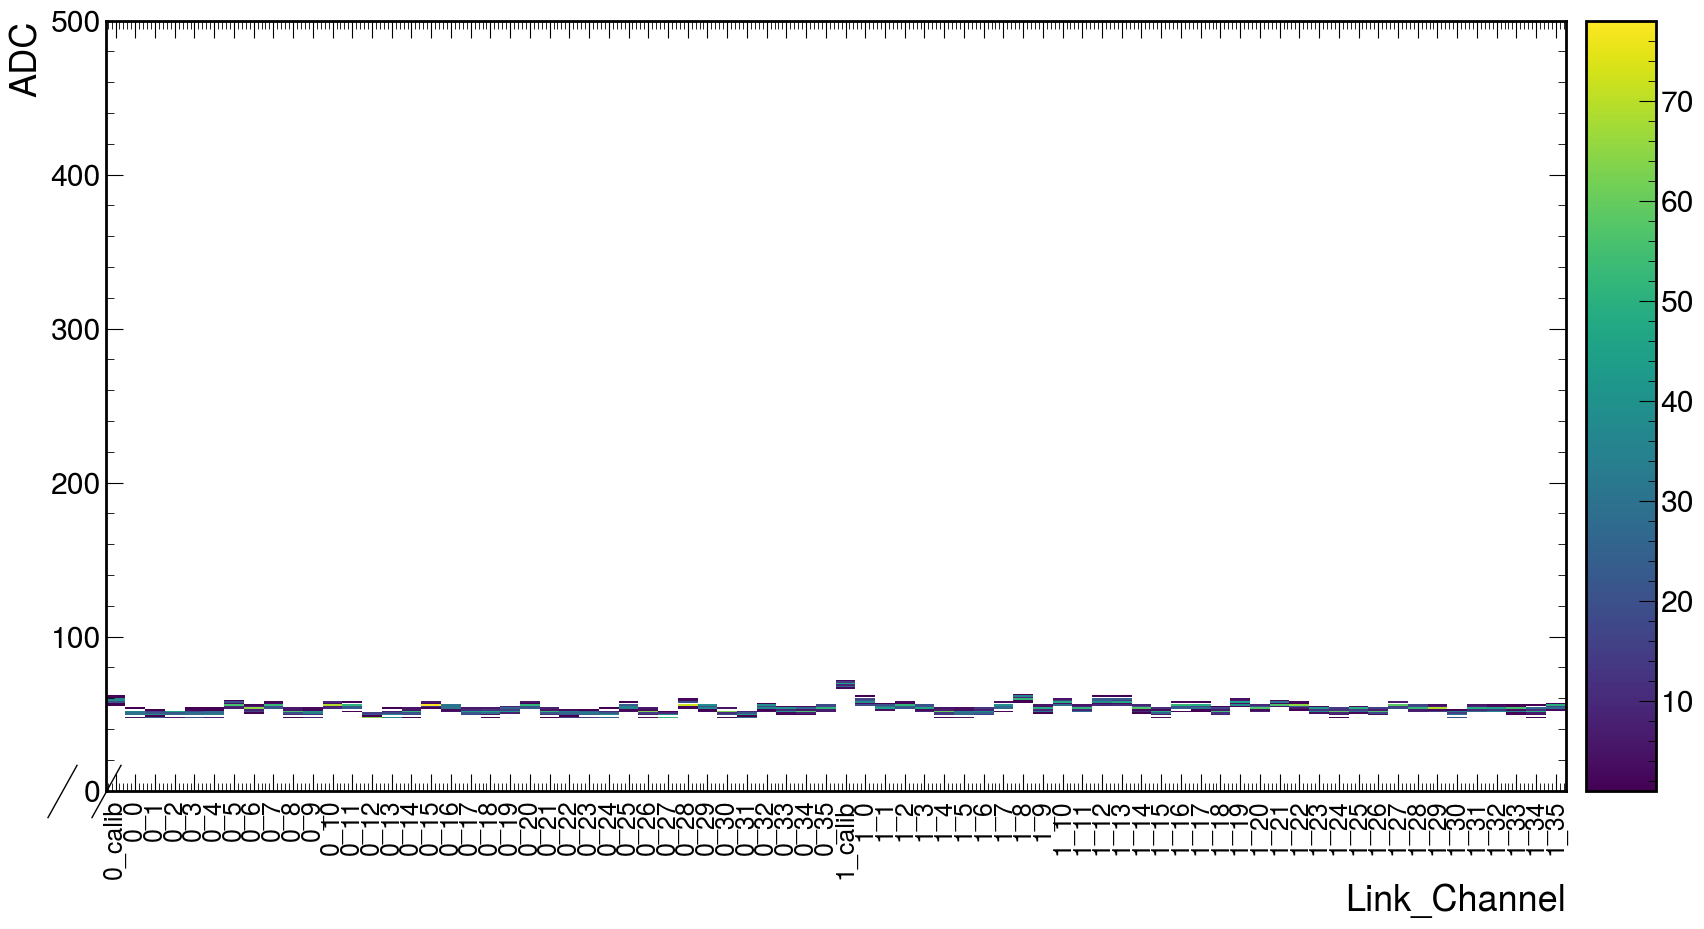

In [7]:
#general ADC Plot
fill_and_plot_all_channels('adc','ADC',0,500)

In [8]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0, 1, 'ADC')

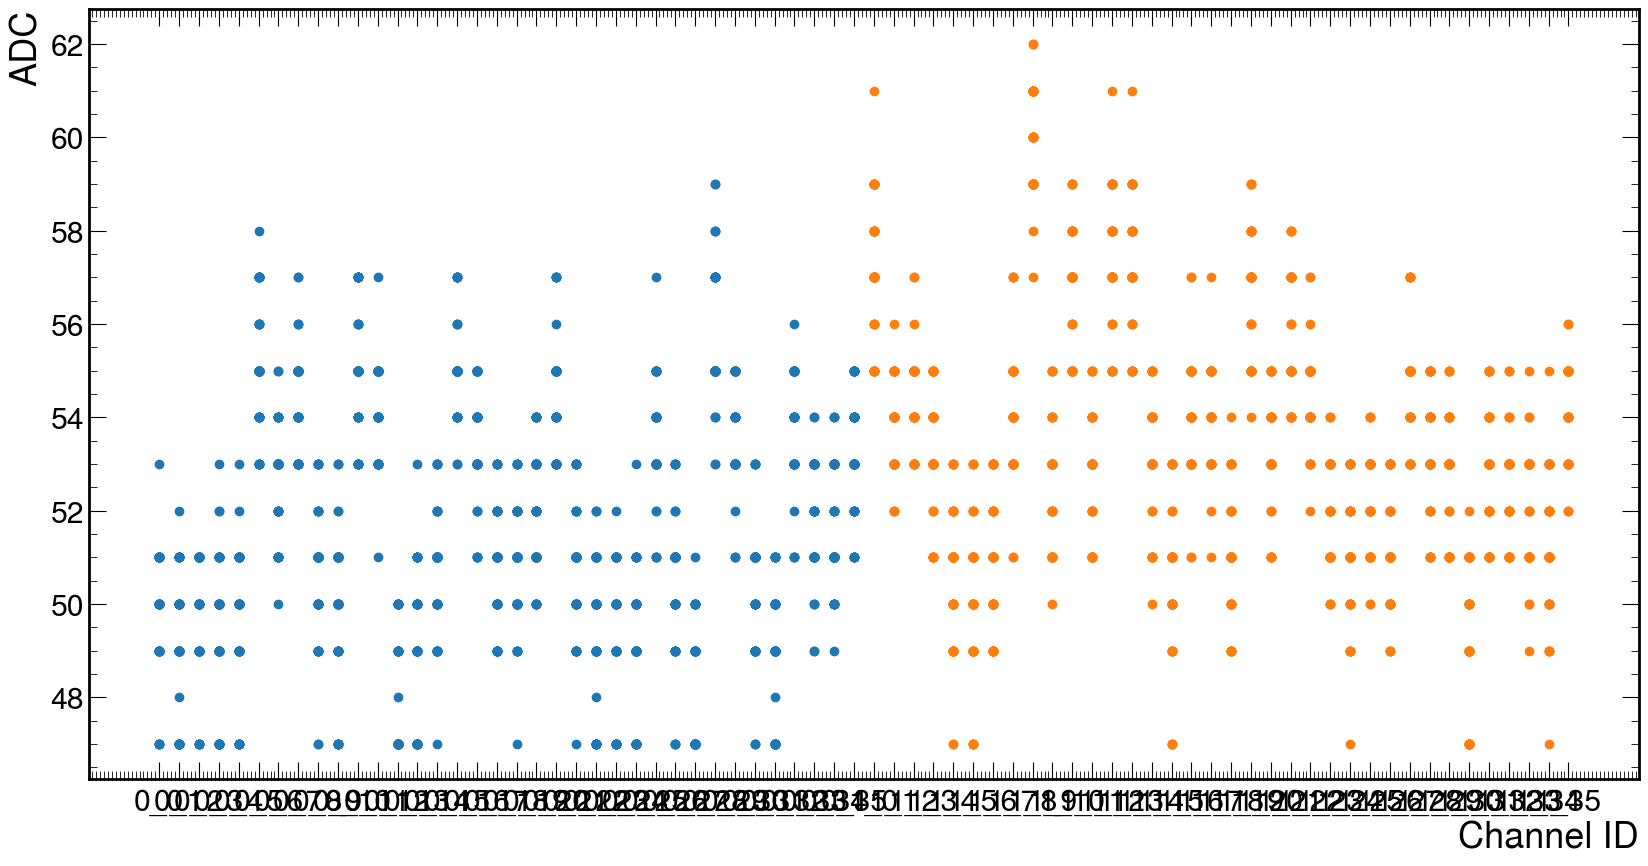

In [9]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.scatter(link_1_norm.uid, link_1_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
#plt.title("Link 0")

Text(0.5, 1.0, 'Link 0')

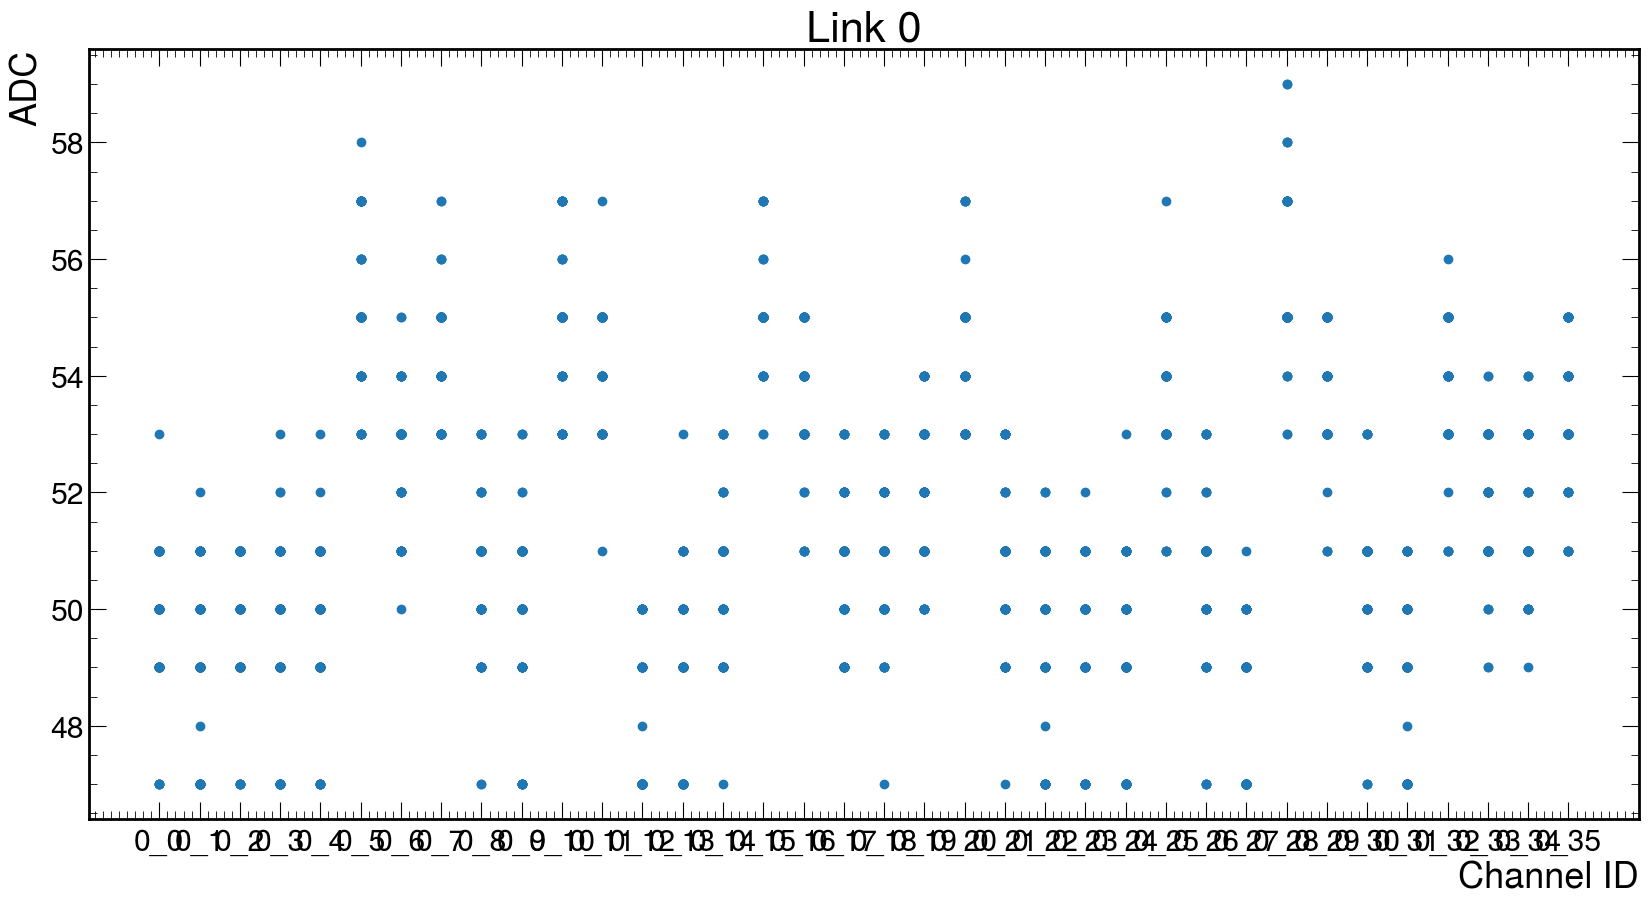

In [10]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [11]:
print ("Link 0 median ADC is " + str(link_0_norm['adc'].median()) + " without calibration channels")
print ("Link 0 mean ADC is " + str(link_0_norm['adc'].mean()) + " without calibration channels")



Link 0 median ADC is 51.0 without calibration channels
Link 0 mean ADC is 51.52916666666667 without calibration channels


Text(0.5, 1.0, 'Link 0')

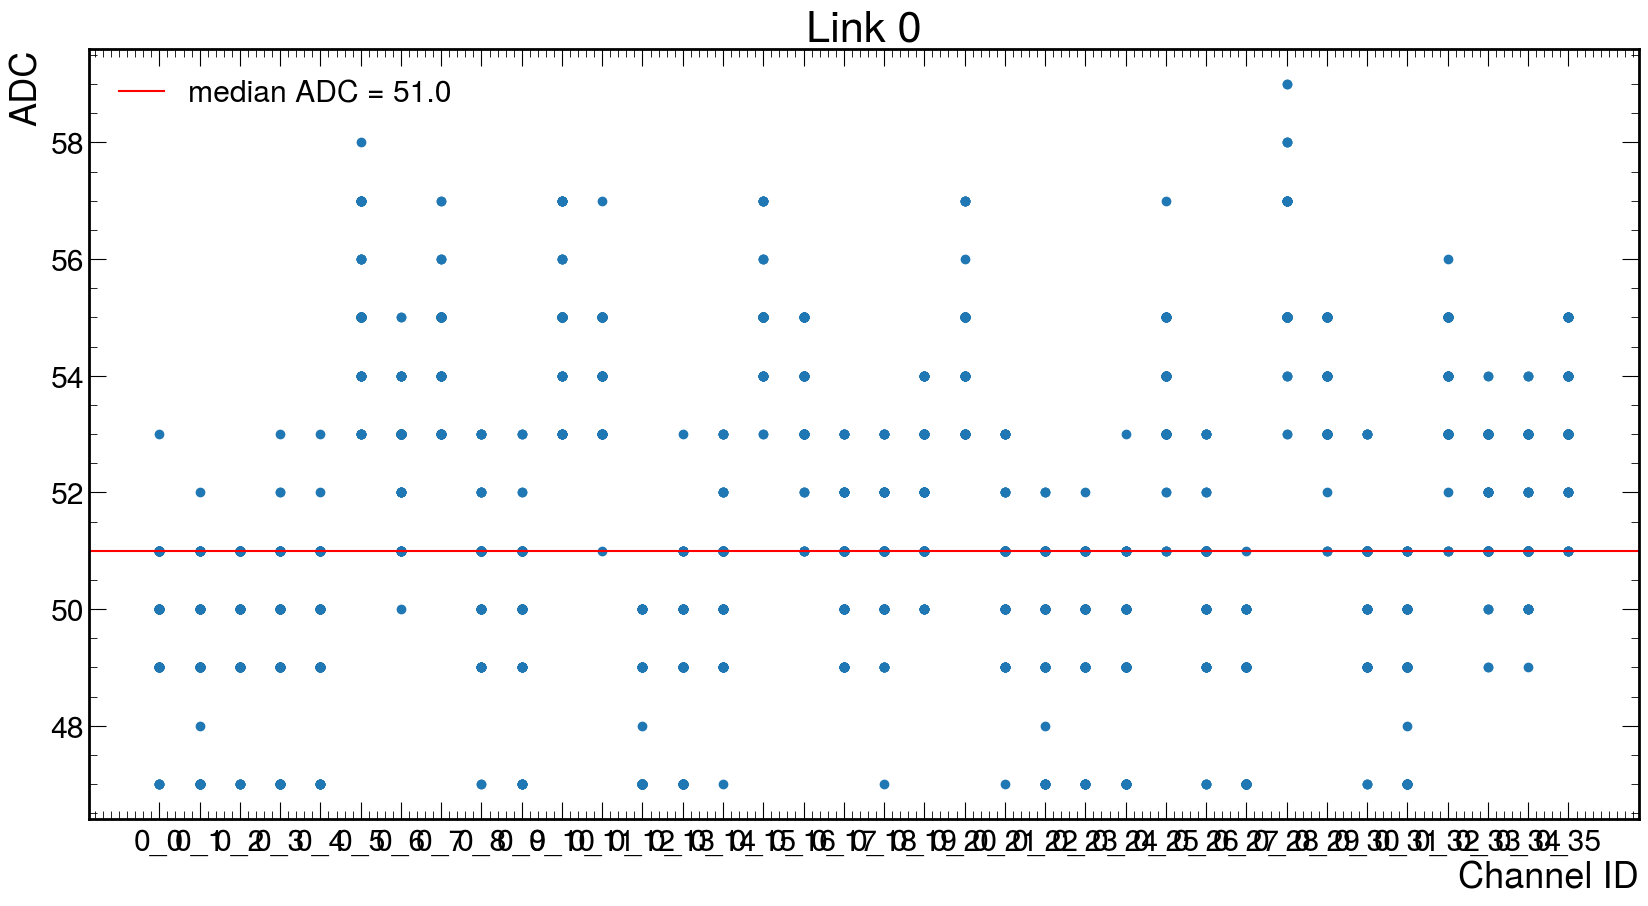

In [12]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.axhline(y=(link_0_norm['adc'].median()), color='r', label = "median ADC = " + str(link_0_norm['adc'].median()) )
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
#plt.axhline(y = 50, color = 'r', label = " new median ADC = 50")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [13]:
print ("Link 1 median ADC is " + str(link_1_norm['adc'].median()) + " without calibration channels")
print ("Link 1 mean ADC is " + str(link_1_norm['adc'].mean()) + " without calibration channels")


Link 1 median ADC is 53.0 without calibration channels
Link 1 mean ADC is 53.43527777777778 without calibration channels


Text(0.5, 1.0, 'Link 1')

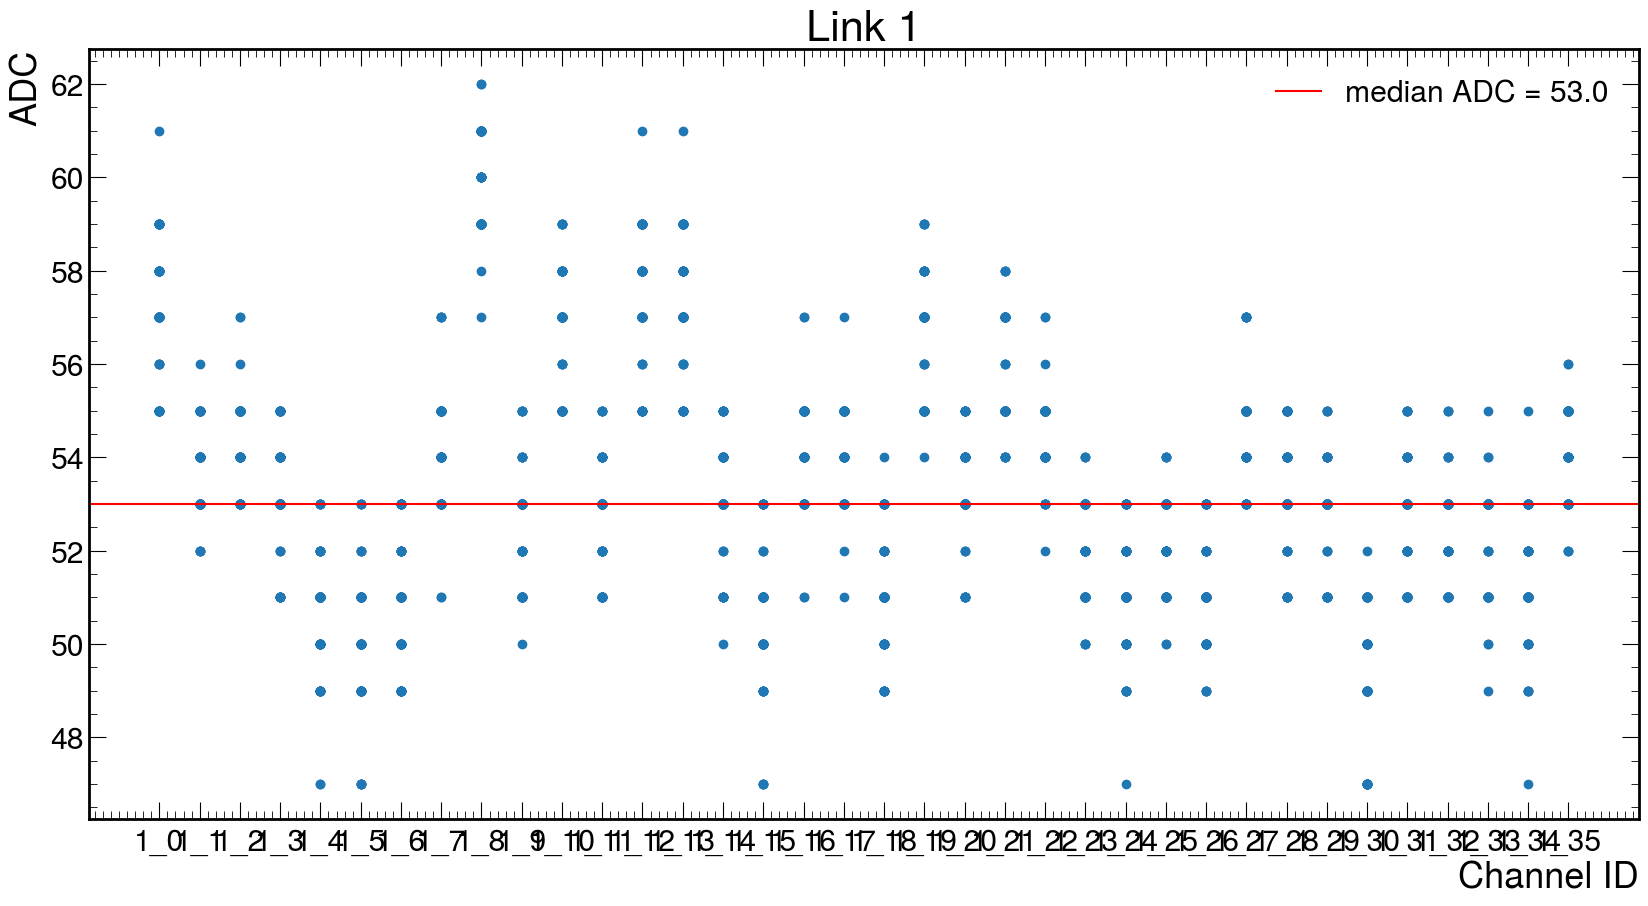

In [14]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
plt.axhline(y=(link_1_norm['adc'].median()), color='r', label = "median ADC = " + str(link_1_norm['adc'].median()) )
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0 " )
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1")

Text(0.5, 1.0, 'Link 0 channel median')

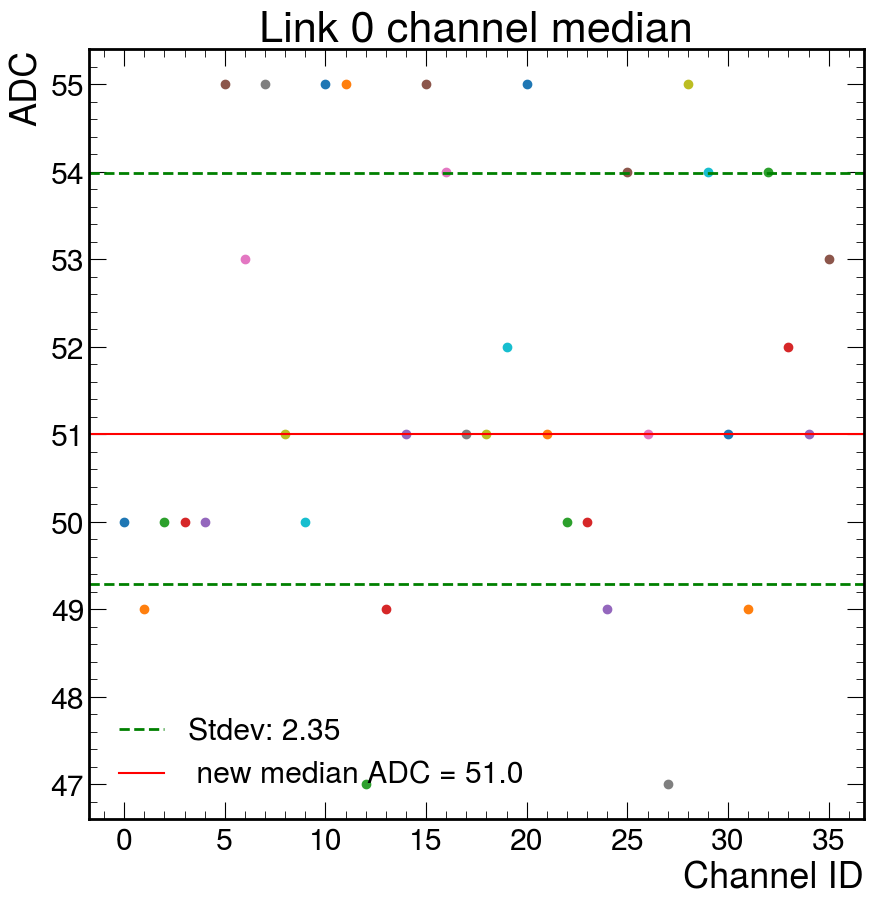

In [15]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
meanVal = np.mean(l0_ch_med)
stdVal = np.std(l0_ch_med)
#plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median")
#print(link_0_std_dev)
#plt.savefig("Link0_inv_vref_50")


In [55]:
len(l0_ch_med)


36

In [56]:
i = 1
l0_ch_med[1]

49.0

In [16]:
dacb_brute_force =[]
trim_inv_brute_force =[]

In [17]:
for i in range(len(l0_ch_med)):
    if l0_ch_med[i] > 51:
        dacb_brute_force.append(i)
    if l0_ch_med[i] < 50:
        trim_inv_brute_force.append(i)
        

In [64]:
trim_inv_brute_force

[1, 12, 13, 24, 27, 31]

In [80]:

with open ('l0_triminv_bf.txt', 'w') as  f:
    f.write('TASKS')
    f.write('\n')
    for i in trim_inv_brute_force:
        csv_name = "ch" + str(i) + "_triminv_scan.csv"
        scan_results_name = "ch" + str(i) + "_triminv_scan_20250819.csv"
        f.write('GEN_SCAN')
        f.write('\n')
        f.write('1')
        f.write('\n')
        f.write(str(i))
        f.write('\n')
        f.write('PEDESTAL')
        f.write('\n')
        f.write('N')
        f.write('\n')
        f.write(csv_name)
        f.write('\n')
        f.write(scan_results_name)
        f.write('\n')
    

hello
ch1_triminv_scan.csv
hello
ch12_triminv_scan.csv
hello
ch13_triminv_scan.csv
hello
ch24_triminv_scan.csv
hello
ch27_triminv_scan.csv
hello
ch31_triminv_scan.csv


In [18]:
dacb_brute_force

[5, 6, 7, 10, 11, 15, 16, 19, 20, 25, 28, 29, 32, 33, 35]

In [71]:
brute_force_settings["CH_1"] ={"TRIM_INV" :62}
brute_force_settings["CH_5"] ={"DACB" : 0, "SIGN_DAC": 1}
brute_force_settings["CH_12"] ={"TRIM_INV" :9}

In [1]:
brute_force_settings["CH_1"] ={"TRIM_INV" :62}

NameError: name 'brute_force_settings' is not defined

In [73]:
brute_force_settings


{'CH_5': {'DACB': 0, 'SIGN_DAC': 1}, 'CH_1': {'TRIM_INV': 62}}

Text(0.5, 1.0, 'Link 1 channel median ')

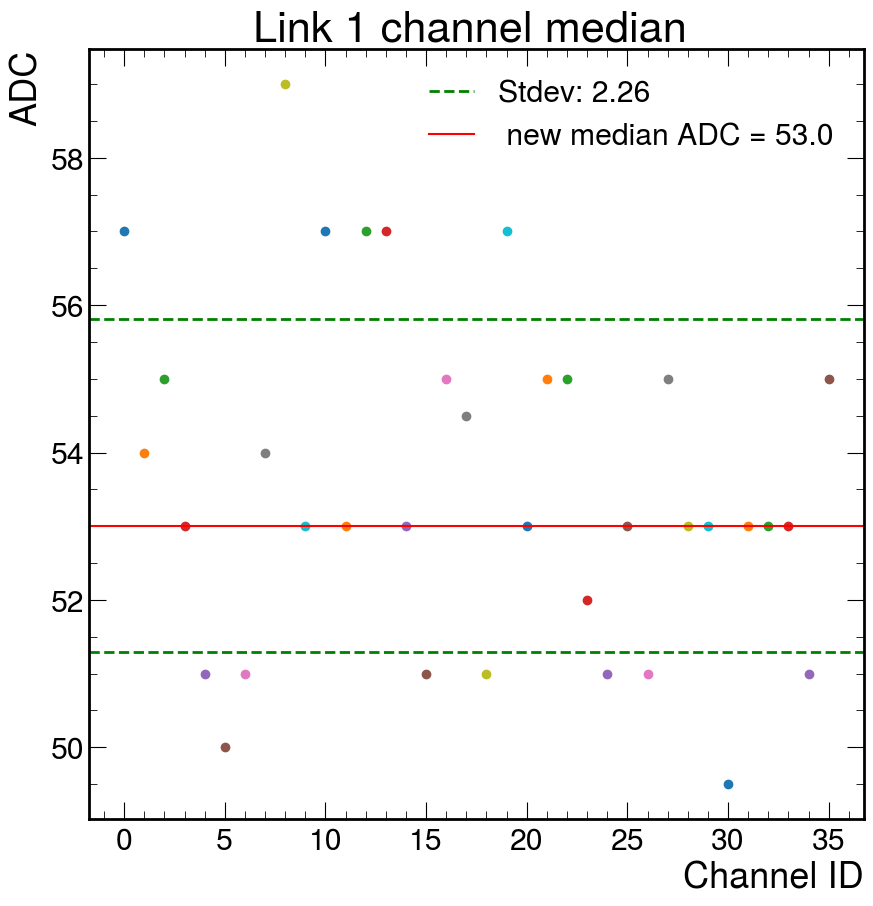

In [51]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC for
meanVal = np.mean(l1_ch_med)
stdVal = np.std(l1_ch_med)
#plt.axhline(meanVal, color='blue', linestyle='dashed', linewidth=2,label=f'Mean: {meanVal}')

plt.axhline(meanVal+ stdVal, color='green', linestyle='dashed', 
           linewidth=2, label=f'Stdev: {stdVal:.2f}')

plt.axhline(meanVal- stdVal, color='green', 
           linestyle='dashed', linewidth=2)
#plt.axhline(y = 49, color = 'g')
#plt.axhline(y = 51, color = 'g')
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+str(link_1_median))

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median ")
#plt.savefig("Link0_inv_vref_50")


Text(0.5, 1.0, 'Link 1 channel median')

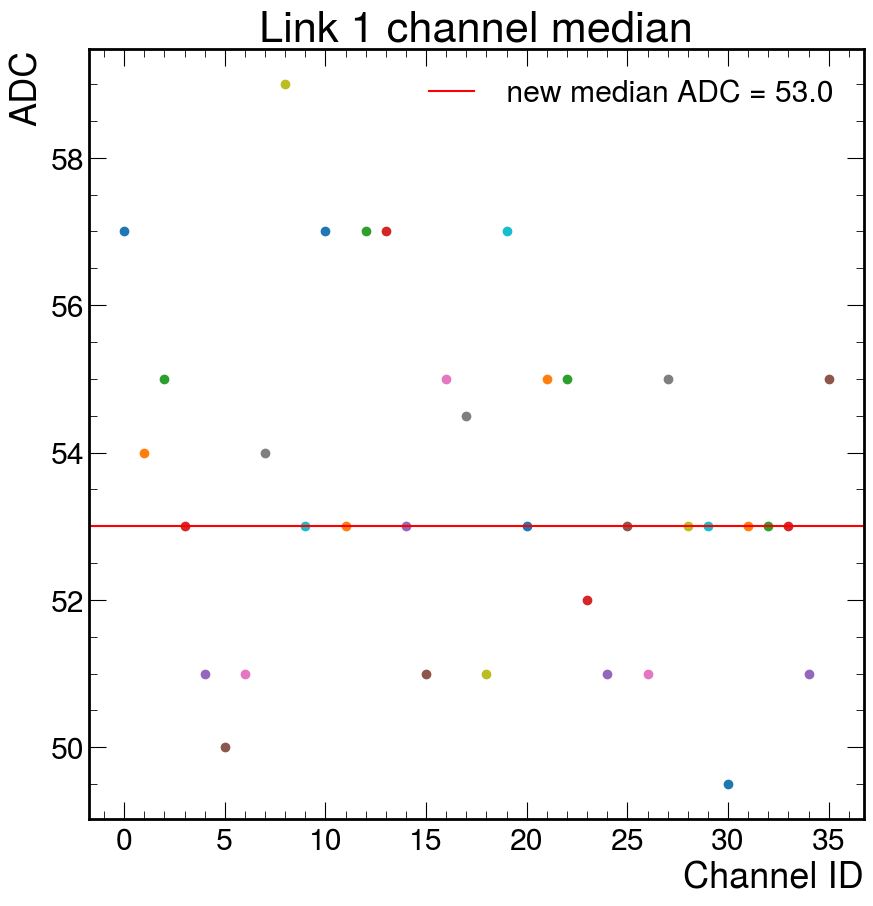

In [52]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0")
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")
#plt.savefig("Link_1_inv_vref_50")

Text(0.5, 1.0, 'Link 1 channel median')

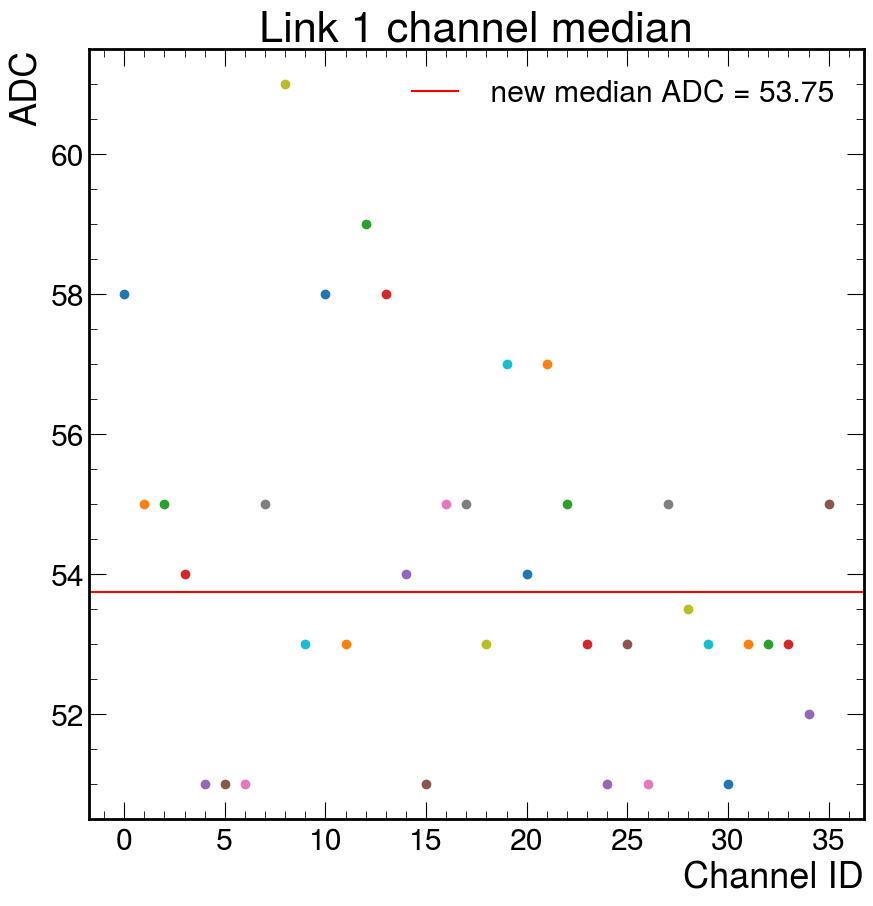

In [38]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0")
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")
#plt.savefig("Link_1_inv_vref_50")